# Análisis exploratorio de frecuencias en resultados históricos de loterías

Este proyecto personal analiza resultados históricos de **Melate**, **Powerball** y **Mega Millions** utilizando Python y pandas.  

El objetivo es practicar un flujo completo de análisis de datos con bases reales: carga, limpieza, estandarización, análisis exploratorio, cálculo de métricas, visualización y exportación de resultados.

> Nota: este proyecto no busca predecir resultados futuros. Las loterías son eventos aleatorios; el análisis es descriptivo y educativo.

## Objetivo del proyecto

Construir un análisis exploratorio que permita:

- Integrar bases históricas de distintas loterías.
- Limpiar fechas y columnas numéricas.
- Calcular frecuencias de aparición por número.
- Identificar últimas apariciones y brechas promedio entre sorteos.
- Visualizar los números más frecuentes por juego.
- Exportar resultados en archivos CSV para consulta posterior.

## 1. Librerías y configuración de rutas

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA = ROOT / "data" / "raw"
PROCESSED_DATA = ROOT / "data" / "processed"

PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

melate_path = RAW_DATA / "Melate_03_06_2026.csv"
mega_millions_path = RAW_DATA / "Mega_Millions_03_06_2026.csv"
powerball_path = RAW_DATA / "Powerball_03_06_2026.csv"

for path in [melate_path, mega_millions_path, powerball_path]:
    if not path.exists():
        raise FileNotFoundError(f"No encontré el archivo: {path}")

print("Archivos localizados correctamente.")

Archivos localizados correctamente.


## 2. Funciones de limpieza y análisis

Estas funciones permiten reutilizar el mismo flujo para distintos juegos, aunque cada archivo tenga una estructura diferente.

In [3]:
def _ensure_datetime(df: pd.DataFrame, date_col: str, dayfirst: bool = False) -> pd.DataFrame:
    """
    Convierte una columna de fecha a formato datetime y elimina filas sin fecha válida.
    """
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce", dayfirst=dayfirst)
    out = out.dropna(subset=[date_col])
    return out

def _analyze_game(
    draws: pd.DataFrame,
    date_col: str,
    main_cols: list[str],
    special_cols: list[str] | None = None,
    top_n: int = 15,
    game_name: str = "Juego"
) -> dict:
    """
    Analiza frecuencias y brechas entre apariciones para un juego de lotería.

    Parámetros:
    - draws: DataFrame con una fila por sorteo.
    - date_col: columna de fecha.
    - main_cols: columnas con números principales.
    - special_cols: columnas con número especial/adicional.
    - top_n: cantidad de números a mostrar en el ranking.
    - game_name: nombre del juego.
    """
    draws = draws.sort_values(date_col).reset_index(drop=True).copy()
    draws["draw_index"] = np.arange(len(draws))  # índice de sorteo (orden temporal)

    def _build_metrics(cols: list[str]):
        # Frecuencias generales
        all_nums = pd.concat([pd.to_numeric(draws[c], errors="coerce") for c in cols], ignore_index=True)
        all_nums = all_nums.dropna().astype(int)
        freq = all_nums.value_counts().sort_index().rename("frecuencia").to_frame()
        freq["proporcion"] = freq["frecuencia"] / freq["frecuencia"].sum()

        # Apariciones por número (para gaps)
        records = []
        freq_reset = freq.reset_index()
        # tomar la primera columna (la de los números) SIN importar su nombre
        num_col = freq_reset.columns[0]
        freq_reset = freq_reset.rename(columns={num_col: "numero"})

        for row in freq_reset.itertuples(index=False):
            num = int(row.numero)

            mask = False
            for c in cols:
                mask = mask | (draws[c].astype("Int64") == num)

            idxs = draws.loc[mask, "draw_index"].to_numpy()
            dates = draws.loc[mask, date_col].to_numpy()

            gaps = np.diff(idxs)  # separaciones en sorteos
            
            rec = {
                "numero": num,
                "apariciones": int(len(idxs)),
                "gap_promedio_sorteos": float(np.mean(gaps)) if len(gaps) else np.nan,
                "gap_mediana_sorteos": float(np.median(gaps)) if len(gaps) else np.nan,
                "gap_min_sorteos": int(np.min(gaps)) if len(gaps) else np.nan,
                "gap_max_sorteos": int(np.max(gaps)) if len(gaps) else np.nan,
                "ultima_fecha": pd.to_datetime(dates[-1]).date().isoformat() if len(dates) else None,
            }
            records.append(rec)

        metrics = pd.DataFrame(records).sort_values(
            ["apariciones", "gap_promedio_sorteos"], ascending=[False, True]).reset_index(drop=True)
        top = metrics.sort_values("apariciones", ascending=False).head(top_n).reset_index(drop=True)

        return freq_reset, metrics.reset_index(drop=True), top

    # Principales
    freq_main, metrics_main, top_main = _build_metrics(main_cols)

    # Especiales
    freq_special = metrics_special = top_special = None
    if special_cols:
        freq_special, metrics_special, top_special = _build_metrics(special_cols)

    return {
        "game": game_name,
        "draws_count": len(draws),
        "min_date": draws[date_col].min().date().isoformat(),
        "max_date": draws[date_col].max().date().isoformat(),
        "freq_main": freq_main,
        "metrics_main": metrics_main,
        "top_main": top_main,
        "freq_special": freq_special,
        "metrics_special": metrics_special,
        "top_special": top_special,}

def _save_tables(outdir: Path, analysis: dict):
    """Guarda las tablas generadas en archivos CSV."""
    outdir.mkdir(parents=True, exist_ok=True)
    game = analysis["game"].replace(" ", "_")

    analysis["freq_main"].to_csv(outdir / f"{game}_freq_main.csv", index=False)
    analysis["metrics_main"].to_csv(outdir / f"{game}_metrics_main.csv", index=False)
    analysis["top_main"].to_csv(outdir / f"{game}_top_main.csv", index=False)

    if analysis["freq_special"] is not None:
        analysis["freq_special"].to_csv(outdir / f"{game}_freq_special.csv", index=False)
        analysis["metrics_special"].to_csv(outdir / f"{game}_metrics_special.csv", index=False)
        analysis["top_special"].to_csv(outdir / f"{game}_top_special.csv", index=False)

def _print_summary(analysis: dict, top_n: int = 15):
    """Imprime un resumen legible del análisis."""
    print("\n" + "=" * 80)
    print(f"{analysis['game']}  |  sorteos analizados: {analysis['draws_count']}")
    print(f"Periodo analizado: {analysis['min_date']} a {analysis['max_date']}")
    print("-" * 80)
    print(f"TOP {top_n} NÚMEROS PRINCIPALES (más repetidos):")
    print(analysis["top_main"].head(top_n).to_string(index=False))

    if analysis["top_special"] is not None:
        print("\nTOP NÚMEROS ESPECIALES / ADICIONALES")
        print(analysis["top_special"].head(top_n).to_string(index=False))
    print("=" * 80)

def plot_top_numbers(analysis: dict, kind: str = "main", top_n: int = 10):
    """Grafica los números más frecuentes de un juego."""
    if kind == "main":
        data = analysis["top_main"].head(top_n)
        title = f"Top {top_n} números principales - {analysis['game']}"
    elif kind == "special":
        if analysis["top_special"] is None:
            print("Este análisis no tiene número especial.")
            return
        data = analysis["top_special"].head(top_n)
        title = f"Top {top_n} números especiales - {analysis['game']}"
    else:
        raise ValueError("kind debe ser 'main' o 'special'.")

    plt.figure(figsize=(10, 5))
    plt.bar(data["numero"].astype(str), data["apariciones"])
    plt.title(title)
    plt.xlabel("Número")
    plt.ylabel("Apariciones")
    plt.xticks(rotation=0)
    plt.show()






## 3. Carga y estandarización de archivos

Cada lotería tiene una estructura distinta, por lo que se crean funciones específicas para cargar y estandarizar cada base.

In [4]:
def load_melate_csv(path: str | Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    # FECHA viene dd/mm/yyyy
    df = _ensure_datetime(df, "FECHA", dayfirst=True)

    # R1..R6 obligatorios
    for c in ["R1","R2","R3","R4","R5","R6"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

    # R7 opcional
    if "R7" in df.columns:
        df["R7"] = pd.to_numeric(df["R7"], errors="coerce").astype("Int64")
    else:
        df["R7"] = pd.NA

    return df[["FECHA","R1","R2","R3","R4","R5","R6","R7"]].dropna(subset=["R1","R2","R3","R4","R5","R6"])

def load_megamillions_csv(path: str | Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = _ensure_datetime(df, "Draw Date", dayfirst=False)

    # "Winning Numbers" = "05 25 30 36 68"
    nums = df["Winning Numbers"].astype(str).str.split().apply(
        lambda xs: [int(x) for x in xs] if len(xs) == 5 else [np.nan]*5
    )
    nums = pd.DataFrame(nums.tolist(), columns=["N1","N2","N3","N4","N5"])

    out = pd.concat([df[["Draw Date","Mega Ball"]], nums], axis=1).rename(
        columns={"Draw Date":"FECHA", "Mega Ball":"MB"}
    )
    for c in ["N1","N2","N3","N4","N5","MB"]:
        out[c] = pd.to_numeric(out[c], errors="coerce").astype("Int64")

    return out.dropna(subset=["N1","N2","N3","N4","N5","MB"])

def load_powerball_csv(path: str | Path) -> pd.DataFrame:
    
    raw = pd.read_csv(path)

    # Limpiar nombres de columnas
    raw.columns = [col.strip() for col in raw.columns]

    date_col = "Draw Date"
    numbers_col = "Winning Numbers"

    if date_col not in raw.columns or numbers_col not in raw.columns:
        raise ValueError(
            f"No encontré las columnas esperadas. Columnas disponibles: {list(raw.columns)}"
        )

    df = raw[[date_col, numbers_col]].copy()

    # Convertir fecha
    df["FECHA"] = pd.to_datetime(df[date_col], errors="coerce")

    # Separar números ganadores
    nums = df[numbers_col].astype(str).str.extract(
        r"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+)"
    )

    nums.columns = ["N1", "N2", "N3", "N4", "N5", "PB"]

    for col in nums.columns:
        nums[col] = pd.to_numeric(nums[col], errors="coerce").astype("Int64")

    out = pd.concat([df[["FECHA"]], nums], axis=1)

    out = out.dropna(subset=["FECHA", "N1", "N2", "N3", "N4", "N5", "PB"])

    return out



## 4. Revisión inicial de las bases

In [5]:
mel = load_melate_csv(melate_path)
mm = load_megamillions_csv(mega_millions_path)
pb = load_powerball_csv(powerball_path)

print("Melate")
display(mel.head())
print(mel.info())

print("\nMega Millions")
display(mm.head())
print(mm.info())

print("\nPowerball")
display(pb.head())
print(pb.info())

Melate


,FECHA,R1,R2,R3,R4,R5,R6,R7
0,2026-05-31,10,14,17,29,49,51,8
1,2026-05-29,10,15,30,35,39,49,44
2,2026-05-27,7,13,15,22,25,49,50
3,2026-05-24,30,33,44,45,46,48,16
4,2026-05-22,13,14,20,50,52,56,44


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4220 entries, 0 to 4219
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   FECHA   4220 non-null   datetime64[ns]
 1   R1      4220 non-null   Int64         
 2   R2      4220 non-null   Int64         
 3   R3      4220 non-null   Int64         
 4   R4      4220 non-null   Int64         
 5   R5      4220 non-null   Int64         
 6   R6      4220 non-null   Int64         
 7   R7      4220 non-null   Int64         
dtypes: Int64(7), datetime64[ns](1)
memory usage: 292.7 KB
None

Mega Millions


,FECHA,MB,N1,N2,N3,N4,N5
0,2026-06-02,12,15,26,43,48,60
1,2026-05-29,7,19,24,47,59,65
2,2026-05-26,7,1,5,49,51,59
3,2026-05-22,8,3,22,34,54,61
4,2026-05-19,6,10,26,34,56,64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2507 entries, 0 to 2506
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   FECHA   2507 non-null   datetime64[ns]
 1   MB      2507 non-null   Int64         
 2   N1      2507 non-null   Int64         
 3   N2      2507 non-null   Int64         
 4   N3      2507 non-null   Int64         
 5   N4      2507 non-null   Int64         
 6   N5      2507 non-null   Int64         
dtypes: Int64(6), datetime64[ns](1)
memory usage: 151.9 KB
None

Powerball


,FECHA,N1,N2,N3,N4,N5,PB
0,2026-06-01,2,42,47,57,58,14
1,2026-05-30,1,27,35,44,52,12
2,2026-05-27,5,14,21,31,51,13
3,2026-05-25,17,32,48,60,64,10
4,2026-05-23,4,16,41,48,66,26


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   FECHA   1948 non-null   datetime64[ns]
 1   N1      1948 non-null   Int64         
 2   N2      1948 non-null   Int64         
 3   N3      1948 non-null   Int64         
 4   N4      1948 non-null   Int64         
 5   N5      1948 non-null   Int64         
 6   PB      1948 non-null   Int64         
dtypes: Int64(6), datetime64[ns](1)
memory usage: 118.1 KB
None


## 5. Análisis de frecuencias por juego

In [6]:
if __name__ == "__main__":
    outdir = PROCESSED_DATA
    top_n = 15

    # --- Melate
    melate_path = RAW_DATA / "Melate_03_06_2026.csv"
    mel = load_melate_csv(melate_path)

    mel_analysis = _analyze_game(
        draws=mel,
        date_col="FECHA",
        main_cols=["R1","R2","R3","R4","R5","R6"],
        special_cols=["R7"],
        top_n=top_n,
        game_name="Melate"
    )
    _print_summary(mel_analysis, top_n=top_n)
    _save_tables(outdir, mel_analysis)

    # --- Mega Millions
    mega_millions_path = RAW_DATA / "Mega_Millions_03_06_2026.csv"
    mm = load_megamillions_csv(mega_millions_path)
    mm_analysis = _analyze_game(
        draws=mm,
        date_col="FECHA",
        main_cols=["N1","N2","N3","N4","N5"],
        special_cols=["MB"],
        top_n=top_n,
        game_name="Mega Millions"
    )
    _print_summary(mm_analysis, top_n=top_n)
    _save_tables(outdir, mm_analysis)

    # --- Powerball
    powerball_path = RAW_DATA / "Powerball_03_06_2026.csv"
    pb = load_powerball_csv(powerball_path)
    pb_analysis = _analyze_game(
        draws=pb,
        date_col="FECHA",
        main_cols=["N1","N2","N3","N4","N5"],
        special_cols=["PB"],
        top_n=top_n,
        game_name="Powerball"
    )
    _print_summary(pb_analysis, top_n=top_n)
    _save_tables(outdir, pb_analysis)

    print("\nListo. Te dejé CSVs en:", outdir.resolve())
    


Melate  |  sorteos analizados: 4220
Periodo analizado: 1984-08-19 a 2026-05-31
--------------------------------------------------------------------------------
TOP 15 NÚMEROS PRINCIPALES (más repetidos):
 numero  apariciones  gap_promedio_sorteos  gap_mediana_sorteos  gap_min_sorteos  gap_max_sorteos ultima_fecha
     32          546              7.722936                  5.0                1               48   2026-05-13
     13          544              7.758748                  6.0                1               51   2026-05-27
     15          544              7.762431                  5.0                1               52   2026-05-29
      1          542              7.741220                  5.0                1               47   2026-03-20
      5          542              7.765250                  6.0                1               43   2026-04-22
     18          542              7.781885                  5.0                1               69   2026-05-15
     36          5

## 6. Resumen general

Esta tabla resume el periodo analizado y el número principal con más apariciones en cada juego.

In [7]:
analyses = [mel_analysis, mm_analysis, pb_analysis]

summary = pd.DataFrame([
    {
        "juego": a["game"],
        "sorteos_analizados": a["draws_count"],
        "fecha_inicial": pd.to_datetime(a["min_date"]).strftime("%d/%m/%Y"),
        "fecha_final": pd.to_datetime(a["max_date"]).strftime("%d/%m/%Y"),
        "numero_principal_mas_frecuente": int(a["top_main"].iloc[0]["numero"]),
        "apariciones": int(a["top_main"].iloc[0]["apariciones"]),
        "proporcion_sobre_sorteos": round(
            float(a["top_main"].iloc[0]["apariciones"]) / float(a["draws_count"]), 4
        ),
        "ultima_fecha": pd.to_datetime(a["top_main"].iloc[0]["ultima_fecha"]).strftime("%d/%m/%Y"),
    }
    for a in analyses
])

display(summary)
summary.to_csv(PROCESSED_DATA / "resumen_general.csv", index=False)

,juego,sorteos_analizados,fecha_inicial,fecha_final,numero_principal_mas_frecuente,apariciones,proporcion_sobre_sorteos,ultima_fecha
0,Melate,4220,19/08/1984,31/05/2026,32,546,0.1294,13/05/2026
1,Mega Millions,2507,17/05/2002,02/06/2026,31,239,0.0953,03/04/2026
2,Powerball,1948,03/02/2010,01/06/2026,28,174,0.0893,20/05/2026


En el resumen general se observa que Melate cuenta con el mayor periodo histórico analizado, con datos desde 1984 hasta 2026. Mega Millions y Powerball tienen menos sorteos analizados, pero permiten comparar juegos con estructuras similares de cinco números principales y un número especial. La columna de proporción sobre sorteos indica el porcentaje de sorteos en los que apareció el número principal más frecuente de cada juego.

## 7. Visualizaciones

Las siguientes gráficas muestran los 10 números principales más frecuentes de cada juego.

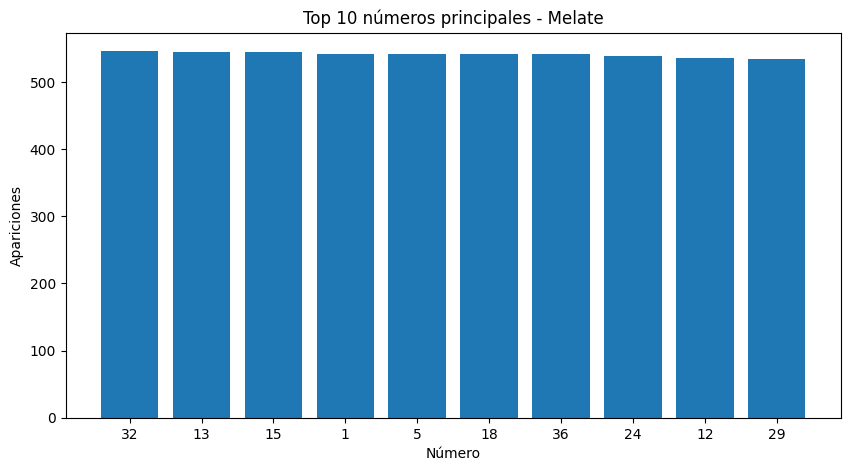

In [8]:
plot_top_numbers(mel_analysis, kind="main", top_n=10)

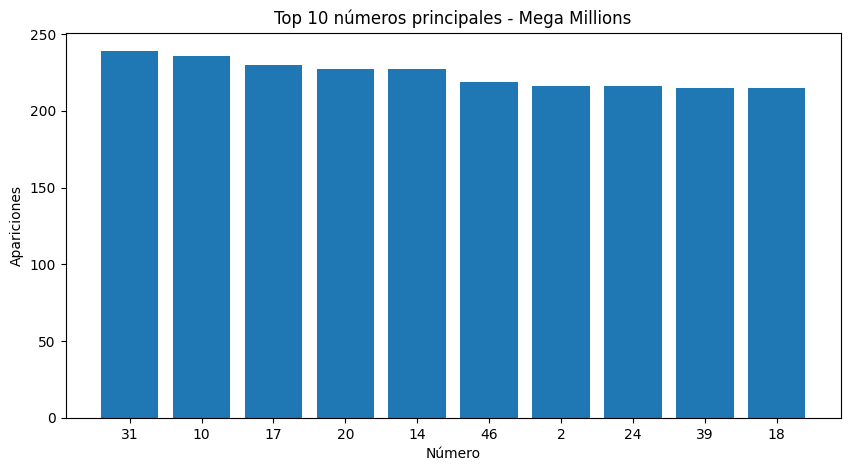

In [9]:
plot_top_numbers(mm_analysis, kind="main", top_n=10)

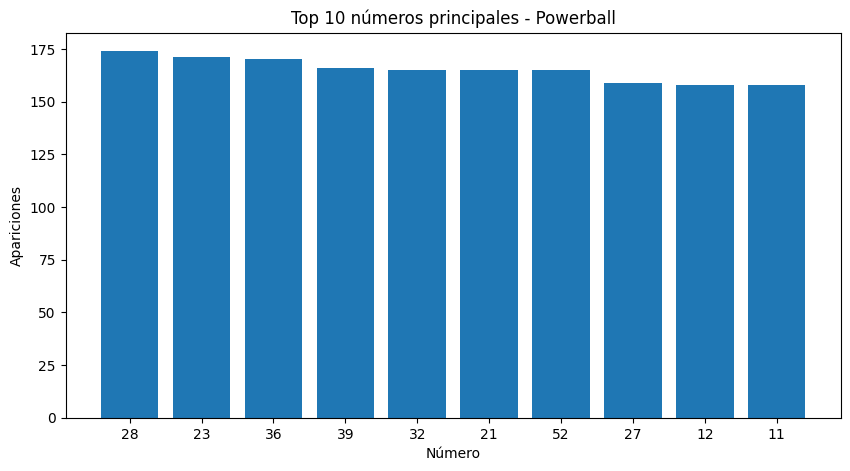

In [10]:
plot_top_numbers(pb_analysis, kind="main", top_n=10)

## 8. Conclusiones

- Se integraron tres bases históricas con estructuras diferentes y se estandarizaron fechas y columnas numéricas.
- El análisis permitió identificar los números con mayor frecuencia histórica, sus proporciones de aparición, últimas fechas y brechas promedio entre sorteos.
- El proyecto demuestra un flujo completo de análisis de datos: carga, limpieza, transformación, análisis exploratorio, visualización y exportación de resultados.
- Los resultados deben interpretarse únicamente como análisis descriptivo. Las frecuencias históricas no permiten predecir sorteos futuros.

